# MODELLING OF THE PIMA INDIANS DIABETES DATASET
## 1.0 Introduction
The Pima Indians Diabetes dataset is a widely used medical dataset originally compiled by the National Institute of Diabetes and Digestive and Kidney Diseases (NIDDK). It contains diagnostic measurements used to assess the presence or absence of diabetes in adult female patients of Pima Indian heritage. The dataset is commonly used in biomedical data science due to its mix of physiological, metabolic, and demographic variables. During prior Exploratory Data Analysis (EDA), the raw dataset was found to contain multiple missing value placeholders (zeroes) which were subsequently cleaned and replaced with NaN values to produce the dataset being used in this analysis.

### 1.1 Objective
The goal of this analysis is to:
1. Assess the quality of the dataset and identify appropriate imputation strategies for missing values
2. Compare KNN Imputation and Iterative Imputation to determine which method reconstructs missing values more accurately using masked-value Mean Absolute Error (MAE).
3. Evaluate the effect of different imputation strategies on the predictive performance of multiple machine learning classifiers.
4. Compare the baseline performance of six classification models using cross-validation.
5. Improve the performance of the top-performing models through hyperparameter tuning prioritizing recall as the primary optimization metric.
6. Perform probability threshold tuning to improve model performance and investigate its effect on the trade-off between recall and precision.
7. Select the most suitable model for diabetes screening based on predictive performance by prioritizing the minimization of false negatives.
8. Evaluate the selected model on an unseen test set and interpret its performance in the context of diabetes prediction.

### 1.2 Dataset Overview
The dataset contains medical diagnostic measurements including glucose levels, blood pressure, skin thickness, insulin, BMI, and diabetes outcome used to create binary outcome classifications for predicting diabetes in females of Pima Indian heritage.  
- Dataset: Pima Indians Diabetes Dataset  
- Source: National Institute of Diabetes and Digestive and Kidney Diseases (NIDDK)
- Number of observations: 768  
- Number of features: 9 (8 predictors, 1 target variable)
- Target variable: Outcome - 0 (non-diabetic), 1 (diabetic)  

#### 1.2.1 Feature Description
- Pregnancies: Number of pregnancies  
- Glucose: Plasma glucose concentration measured  
- Blood Pressure: Diastolic Blood Pressure  
- Skin Thickness: Triceps skin fold Thickness  
- Insulin: 2-hour serum Insulin  
- BMI: Body Mass Index  
- Diabetes Pedigree Function: Genetic diabetes score using family history  
- Age: Age in years  
- Outcome: Diabetes diagnosis (binary classification)  


In [21]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_absolute_error

from sklearn.impute import KNNImputer

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

## 2.0 Data Preparation for Modelling
### 2.1 Data Inspection
Loading and inspecting the cleaned file for further cleaning via imputation of missing values

In [22]:
df = pd.read_csv("../data/diabetes_cleaned.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [23]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,NaN,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,NaN,NaN,30.1,0.349,47,1
767,1,93.0,70.0,31.0,NaN,30.4,0.315,23,0


In [24]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### 2.2 Dataset Overview and Imputation Method Decision
The two major areas to address within the  dataset are:

1. The dataset contains multiple missing values specifically in Glucose, BMI, Blood Pressure, Insulin and Skin Thickness, which displayed a clustered and hierarchical missingness such that one missingness group was a subset of the other, i.e., participants displayed missing values for multiple variables, disrupting the possibility of Missingness Completely At Random (MCAR). However, no meaningful patterns were observed within the missingness subgroups during EDA, leaving Missingness At Random(MAR) and Missingness Not At Random (MNAR) undetermined.

Regardless, the use of mean or median for imputation would not be optimal as they ignore the relationships between variables, introducing bias. Methods such as K-Nearest Neighbours(KNN) and Iterative Imputation using Multivariate Imputation by Chained Equations (MICE) would be more rigorous at preserving these multivariable relationships given that the dataset contains variables that are metabolically related, and the aforementioned methods use information from other variables to estimate missing values. 

2. Despite being flagged to contain several statistical outliers, variables such as Insulin, displayed rare but not physiologically impossible values that substantially deviated from the median, further distorting the dataset, however, they likely represent rare subsets of the population, that should not be under-represented.

It is also important to note:
1. Iterative Imputer likely stands as a more viable imputation method given that the variables are biologically related to each other, there are multiple missing values per participant(structural missingness) and it is less affected by large size of missingness, i.e. Insulin and Skin thickness missingness accounting for 49% and 34% of the dataset.KNN however, would have to rely on the remaining available features and participants.
2. Despite this, a comparison of the two methods would still be done to rigorously determine the more effective imputation method.


With regards to KNN:
1. With 768 observations in the dataset, k = 5 could be used as it is a commonly adopted default for datasets that are moderately sized. However, a sub-analysis would be conducted to determine the optimal value of k to provide effective imputation values.

## 3.0 Imputation
### 3.1 Splitting the dataset into features(X) and prediction target(y)
All features in the dataset include: Pregnancies, Glucose, Blood Pressure, Skin Thickness, Insulin, BMI, Diabetes Pedigree Function, Age and Outcome as the prediction target.

In [25]:
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
X = df[features]
y = df['Outcome']

X

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63
764,2,122.0,70.0,27.0,NaN,36.8,0.340,27
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30
766,1,126.0,60.0,NaN,NaN,30.1,0.349,47


### 3.2 Separating the features (x) and prediction target (y) into train and test data

In [26]:
train_X, test_X, train_y, test_y = train_test_split(X, y, random_state = 42, test_size = 0.2, stratify = y)

### 3.3 Normalizing the values for the different features
Given that each variable is measured on a different scale, and KNN is reliant on the distances between the target and the nearest neighbours to impute missing values, all features would need to be normalized to prevent bias. Min Max Scaler is most likely to be affected by outliers, and although Robust Scaler is more resistant to outliers, the extreme values in the dataset are clinically plausible rather than measurement errors, therefore Standard Scaler is a suitable default to standardize the data while also preserving the influence of these observations.
Iterative Imputer does not require prior scaling before imputation, but it would be done to ensure consistency and comparability.

In [27]:
scaler = StandardScaler()
scaled_train_X = pd.DataFrame(scaler.fit_transform(train_X), columns = train_X.columns, index = train_X.index)

### 3.4 Performing artificial masking to determine the optimal k
In order to determine the optimal value of k that produces the most accurate imputation for KNN, a portion of the dataset would be artificially masked, imputed via each respective k value and compared against the original values to produce a Mean Absolute Error (MAE) per feature. These are further averaged to produce an overall MAE per value of k. 

Notes on masking:
1. Masking will be conducted on only variables that exhibited missingness in the original dataset (Glucose, BMI, Blood Pressure, Skin Thickness and Insulin).
2. It will also be iterated 10 times, suitable for a dataset of this size to ensure a more robust estimation of imputation performance and prevent drawing conclusions based on one iteration.
3. It will also be performed on the full incomplete dataset(train_X) rather than on the portion of the dataset with non-missing values. This is owing to the nature of structural missingness observed, allowing the imputer to perform in the presence of the observed missingness patterns rather than the 'unproblematic' or complete portion of the dataset.
4. Given that the imputer is performing on the incomplete dataset(train_X), there is less need to mimic missingness or replicate the observed missingness, and a uniform masking would still be an appropriate evaluation strategy.

#### 3.4.1 Creating a function to mask, impute via KNN and Iterative Imputer, and obtain an overall mae for each imputer

In [28]:
seeds = range(42, 53)
features = ['Glucose', 'BMI', 'BloodPressure', 'SkinThickness', 'Insulin']

def mask_impute_mae(n_neighbour = None):
    seed_maes = []
    for seed in seeds:
        feature_maes = []
        feature_indices = {}
        rng = np.random.default_rng(seed)
        masked_train_X = scaled_train_X.copy()
        actual_values = scaled_train_X.copy()
        for feature in features:
            observed_indices = scaled_train_X.index[scaled_train_X[feature].notna()].tolist()
            selected_indices = rng.choice(observed_indices, size = int(0.2*len(observed_indices)), replace = False)
            masked_train_X.loc[selected_indices, feature] = np.nan
            feature_indices[feature] = selected_indices
        if n_neighbour is None:
            imputer = IterativeImputer(random_state = 42, max_iter = 50)
        else: 
            imputer = KNNImputer(n_neighbors = n_neighbour)   
        imputed_train_X = pd.DataFrame(imputer.fit_transform(masked_train_X), columns = masked_train_X.columns, index = masked_train_X.index)
        for column, rows in feature_indices.items():
            mae = mean_absolute_error(actual_values.loc[rows, column], imputed_train_X.loc[rows, column])
            feature_maes.append(mae)
        seed_maes.append(np.mean(feature_maes))
    overall_mae = np.mean(seed_maes)
    return overall_mae

#### 3.4.2 Finding an optimal K-value for KNN and comparing the two imputers
Calling the `mask_impute_mae` function, determining the optimal k-value for KNN imputation and comparing MAEs between the two imputers to identify the imputer with the best imputation accuracy

In [29]:
#optimal k via smallest mae for KNNImputer
k_mae = {}
smallest_mae = None
n_neighbours = range(1, 61) # the k-values 
for n_neighbour in n_neighbours:
    k_mae[n_neighbour] = mask_impute_mae(n_neighbour)

for key, value in k_mae.items():
    if smallest_mae is None:
        smallest_mae = value
        optimal_k = key
    elif value < smallest_mae:
        smallest_mae = value
        optimal_k = key
    knn_mae = smallest_mae
        
print(f"the optimal k for knn is {optimal_k} gotten from the smallest mean absolute error of {knn_mae}")

# mae for IterativeImputer
ii_mae = mask_impute_mae()
print(f"the mae for iterative imputer is {ii_mae}")

# determining which imputer produced the least mae
if ii_mae > knn_mae:
    print("KNN produced the least errors in imputation")
elif knn_mae > ii_mae:
    print("Iterative Imputer produces the least errors in imputation")
else:
    print("both are equal")

the optimal k for knn is 38 gotten from the smallest mean absolute error of 0.6782903091269021
the mae for iterative imputer is 0.6661599404618223
Iterative Imputer produces the least errors in imputation


#### 3.4.3 Plotting the relationship between number of neighbours(k) and Mean Absolute Error (MAE) 

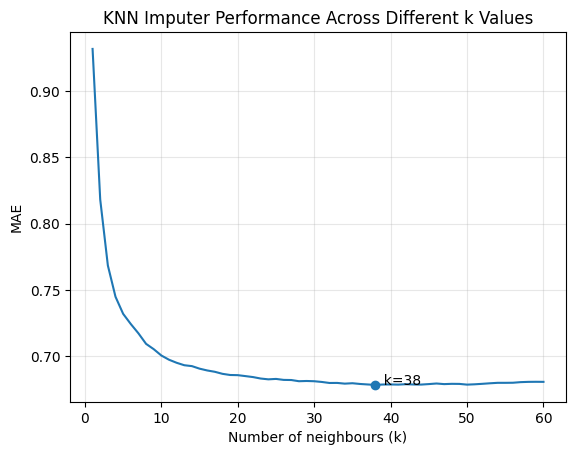

In [30]:
sns.lineplot(x=k_mae.keys(), y=k_mae.values())
plt.title("KNN Imputer Performance Across Different k Values")
plt.xlabel("Number of neighbours (k)")
plt.ylabel("MAE")
plt.grid(alpha=0.3)
plt.scatter(optimal_k, k_mae[optimal_k])
plt.text(optimal_k, k_mae[optimal_k], f"  k={optimal_k}")
plt.show()

KNN imputation performance improved with increasing number of neighbours, before displaying a plateau in values after reaching an optimal k value of 38. However, Iterative Imputer displayed a slightly lower MAE, suggesting a marginally better imputation of missing values. Both imputation methods will be retained for model evaluation to assess their effect on classification model performance.


### 3.5 KNN and Iterative Imputation
Creating an imputation function using the optimized KNN imputer and Iterative Imputer, calling the function, and storing the newly imputed dataset.


*Note: In this analysis, manual preprocessing was performed prior to cross-validation, however, in an ideal workflow, this preprocessing would be integrated into a scikit-learn 'Pipeline' to ensure that each fold is preprocessed independently and reduce preprocessing data leakage*

In [31]:
def imputation(imputer):
    selected_imputer = imputer
    imputer_name = type(imputer).__name__
    imputed_train_dict[f"{imputer_name}_scaled_train_X"] = selected_imputer.fit_transform(scaled_train_X)
    imputed_test_dict[f"{imputer_name}_scaled_test_X"] = selected_imputer.transform(scaled_test_X)
    imputed_train_dict[f"{imputer_name}_original_train_X"] = pd.DataFrame(scaler.inverse_transform(imputed_train_dict[f"{type(imputer).__name__}_scaled_train_X"]), columns = train_X.columns, index = train_X.index)
    imputed_test_dict[f"{imputer_name}_original_test_X"] = pd.DataFrame(scaler.inverse_transform(imputed_test_dict[f"{type(imputer).__name__}_scaled_test_X"]), columns = test_X.columns, index = test_X.index)   


scaled_test_X = pd.DataFrame(scaler.transform(test_X), columns = test_X.columns, index = test_X.index)

imputed_train_dict = {}
imputed_test_dict = {}
imputers = [KNNImputer(n_neighbors = optimal_k), IterativeImputer(random_state = 42, max_iter = 50)]
for imputer in imputers:
    imputation(imputer)

### 3.6 Model Comparison
Using the imputed data, six machine learning models will be evaluated and compared with the baseline and against each other (Logistic Regression, Decision Tree, Random Forest, KNN Classifier, Support Vector Machines (SVM) and XGBoost). The models will first undergo a cross validation test using default hyperparameters, and their performances will be evaluated using measures of separation (ROC-AUC), to determine how well the models are at separating diabetic from non-diabetic participants, prior to selecting the most promising models.
The best-performing models will undergo hyperparameter tuning using GridSearch 5-fold cross validation, and their subsequent performance compared against their untuned predecessors. Given the context of the experiment, recall factor would be prioritized to obtain the model with the best predictive power for diabetic patients and minimize false negatives.

With the logistic regression model serving as a baseline classifier, five other models were also selected and will be subsequently trained and tested to obtain the best performing model for diabetes prediction. 

Notes on the models:
1. Linear classification models like the Logistic Regression models are likely to struggle with non-linear relationships between variables within the dataset, however, it will serve as a suitable baseline classifier for the evaluation.
2. A decision tree model would be better at handling non-linearity but is more likely to overfit the data without proper control. 
3. A random forest model was selected as an improvement upon the decision tree as it combines multiple trees, providing less overfitting, but is less interpretable than the above models.
4. A distance-based KNN Classifier was also selected as it makes no assumptions about the data distribution, but is more sensitive to scaling
5. The SVM model helps to find the best boundary between diabetic and non-diabetics but may require careful tuning if ranked as a top performing model during evaluation.
6. A gradient boosting ensemble i.e. XGBoost was selected for its high predictive performance, but is more complex and computationally expensive.
Overall, these models were chosen because of their ability to handle non-linear relationships and complex interactions between the features that Logistic Regression cannot capture.

In [32]:
models = [LogisticRegression(random_state = 42),
          DecisionTreeClassifier(random_state = 42),
          RandomForestClassifier(random_state = 42),
          CalibratedClassifierCV(SVC(random_state=42), ensemble=False),
          KNeighborsClassifier(),
          XGBClassifier(random_state = 42)]

scaled_models = (LogisticRegression, KNeighborsClassifier, CalibratedClassifierCV)


results = []
    
for model in models:
  for imputer in imputers:
    imputer_name = type(imputer).__name__
    model_name = type(model).__name__
    if isinstance(model, scaled_models):
        scores = cross_validate(model, imputed_train_dict[f"{imputer_name}_scaled_train_X"], train_y, cv = 5, scoring = {"roc_auc" : "roc_auc", "recall": "recall", "f1" : "f1"})

    else:
        scores = cross_validate(model, imputed_train_dict[f"{imputer_name}_original_train_X"], train_y, cv = 5, scoring = {"roc_auc" : "roc_auc", "recall": "recall", "f1" : "f1"})

    results.append({
        'Model' : model_name,
        'Imputer' : imputer_name,
        'Mean ROC-AUC' : scores['test_roc_auc'].mean(),
        'ROC-AUC STD' : scores['test_roc_auc'].std(),
        'Mean Recall' : scores['test_recall'].mean(),
        'Mean F1' : scores['test_f1'].mean()
        })

baseline_results = pd.DataFrame(results)
baseline_results.sort_values(by="Mean ROC-AUC", ascending=False)


,Model,Imputer,Mean ROC-AUC,ROC-AUC STD,Mean Recall,Mean F1
0,LogisticRegression,KNNImputer,0.842762,0.029398,0.593688,0.661285
1,LogisticRegression,IterativeImputer,0.842357,0.029273,0.589037,0.656090
7,CalibratedClassifierCV,IterativeImputer,0.827712,0.028465,0.546512,0.625490
6,CalibratedClassifierCV,KNNImputer,0.826476,0.027178,0.551163,0.624494
4,RandomForestClassifier,KNNImputer,0.825889,0.016104,0.574751,0.630508
5,RandomForestClassifier,IterativeImputer,0.824961,0.016839,0.588926,0.626893
8,KNeighborsClassifier,KNNImputer,0.810462,0.032143,0.635548,0.652816
9,KNeighborsClassifier,IterativeImputer,0.808499,0.029421,0.640310,0.651510
11,XGBClassifier,IterativeImputer,0.792990,0.022177,0.556478,0.590968
10,XGBClassifier,KNNImputer,0.785233,0.017749,0.584164,0.597546


A minimal difference in mean ROC-AUC for each imputer per model indicates that there is no substantial difference in the effect of both imputers on model performance.

The Logistic Regression model coupled with the KNN imputer is observed to have the highest mean ROC-AUC indicating the largest separation of values between diabetics and non diabetics, with its Iterative Imputer counterpart following closely behind. The Calibrated Classifier(SVM) model and Random Forest Classifier were also observed among the top three performing models.

Although Logistic Regression displayed a slightly higher mean ROC-AUC, Random Forest Classifier displayed the greatest stability with the lowest standard deviation of approximately 0.016 to 0.017 depending on imputer, while KNeighbours Classifier displayed the highest recall.

The Decision Tree Classifier displayed the least ROC-AUC performance among the six models, possibly due to overfitting on the training data, and contrary to expectation, XGBoost Classifier underperformed, displaying the second-to-least value separation.

From the results, three models will be chosen for hyperparameter tuning:
1. Logistic Regression model, as it displayed the highest mean ROC-AUC
2. Calibrated Classifier (SVC) because it displayed the second-highest mean ROC-AUC
3. Random Forest Model because it displayed the highest stability (consistency of ROC-AUC values).

### 4.0 Hyperparameter Tuning
Given the context of the experiment, the recall metric is prioritized during tuning to minimize false negatives, allowing more diabetic participants to be identified. Therefore, models will be selected based on recall, with the remaining parameters providing additional insight into overall model quality.

In [33]:
lr_param_grid = {
    "C": [0.001, 0.01, 0.05, 0.1, 1, 10],
    "solver": ["lbfgs", "liblinear"]
}

svm_param_grid = {
    "estimator__C":[0.01,0.1,1,10,100],
    "estimator__kernel":["linear","rbf"],
    "estimator__gamma":["scale","auto",0.01,0.1]
}

rf_param_grid = {
    "n_estimators": [100,200,300],
    "max_depth": [None,5,10,20],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,5],
    "max_features":["sqrt","log2"]
}

model_param = {
    LogisticRegression(random_state = 42) : lr_param_grid,
    CalibratedClassifierCV(SVC(random_state = 42), ensemble = False) : svm_param_grid,
    RandomForestClassifier(random_state = 42) : rf_param_grid,
    }

tuned_models = []

for estimator, parameter in model_param.items():
        model_name = type(estimator).__name__   
        for imputer in imputers:
            imputer_name = type(imputer).__name__
            grid = GridSearchCV(estimator = estimator, param_grid = parameter, scoring = {"ROC_AUC" : "roc_auc", "Recall" : "recall", "F1" : "f1" }, refit = "Recall", cv = 5, n_jobs = -1)
            if isinstance(estimator, scaled_models):
                grid.fit(imputed_train_dict[f"{imputer_name}_scaled_train_X"], train_y)
            else:
                grid.fit(imputed_train_dict[f"{imputer_name}_original_train_X"], train_y)


            tuned_models.append({ 
                "Model" : model_name,
                "Imputer" : imputer_name,
                "Best parameters" : grid.best_params_,
                "Best score (Recall)" : grid.best_score_,
                "ROC_AUC" : grid.cv_results_['mean_test_ROC_AUC'][grid.best_index_],
                "F1" : grid.cv_results_['mean_test_F1'][grid.best_index_],
                "Best estimator" : grid.best_estimator_
                })


tuned_models = pd.DataFrame(tuned_models)

tuned_models = tuned_models.sort_values(by = "Best score (Recall)", ascending = False)

tuned_models

,Model,Imputer,Best parameters,Best score (Recall),ROC_AUC,F1,Best estimator
1,LogisticRegression,IterativeImputer,"{'C': 0.001, 'solver': 'liblinear'}",0.667996,0.838433,0.666024,"LogisticRegression(C=0.001, random_state=42, s..."
2,CalibratedClassifierCV,KNNImputer,"{'estimator__C': 0.01, 'estimator__gamma': 'au...",0.658804,0.831244,0.677418,"CalibratedClassifierCV(ensemble=False,\n ..."
0,LogisticRegression,KNNImputer,"{'C': 0.001, 'solver': 'liblinear'}",0.658693,0.837836,0.649085,"LogisticRegression(C=0.001, random_state=42, s..."
3,CalibratedClassifierCV,IterativeImputer,"{'estimator__C': 0.01, 'estimator__gamma': 'au...",0.654042,0.830026,0.672395,"CalibratedClassifierCV(ensemble=False,\n ..."
5,RandomForestClassifier,IterativeImputer,"{'max_depth': None, 'max_features': 'log2', 'm...",0.621595,0.829286,0.652789,"(DecisionTreeClassifier(max_features='log2', m..."
4,RandomForestClassifier,KNNImputer,"{'max_depth': None, 'max_features': 'log2', 'm...",0.612403,0.827256,0.645513,"(DecisionTreeClassifier(max_features='log2', m..."


Comparing against the baseline models, an improvement in recall is observed across all three models with Logistic Regression displaying the largest improvement from 0.589 to 0.668, with a marginal change in ROC-AUC and a slightly improved F1 score of 0.656 to 0.666. This indicates that the model improved in sensitivity to diabetes prediction with little decrease in overall discriminative ability.
The Calibrated Classifier (SVM) and Random Forest Classifier also showed an improvement in recall when paired with the KNN imputer and Iterative Imputer respectively, however, Random Forest with both imputers still displayed the lowest mean ROC-AUC and recall among the three models.

### 5.0 Threshold Optimization
Threshold tuning will be conducted to further improve recall and model sensitivity before final evaluation on the unseen test set.
The top three performing models will be tested across varying thresholds, using out of fold predictions to reduce leakage, and the final thresholds will be sorted. 

In [34]:
threshold_results = []

for i in range(3):
    best_model = tuned_models.iloc[i]["Best estimator"]
    model_name = tuned_models.iloc[i]["Model"]
    imputer_name = tuned_models.iloc[i]["Imputer"]

    for imputer in imputers:
        if imputer_name == type(imputer).__name__:
            if isinstance(best_model, scaled_models):
                train_data = imputed_train_dict[f"{imputer_name}_scaled_train_X"]

            else:
                train_data = imputed_train_dict[f"{imputer_name}_original_train_X"] 

            probabilities = cross_val_predict(best_model, train_data, train_y, cv=5, method="predict_proba")[:,1]

            thresholds = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

            for threshold in thresholds:

                predictions = (probabilities >= threshold ).astype(int)


                threshold_results.append({
                    "Model" : model_name,
                    "Imputer" : imputer_name,
                    "Threshold" : threshold,
                    "Recall" : recall_score(train_y, predictions),
                    "Precision" : precision_score(train_y, predictions),
                    "F1": f1_score(train_y, predictions),
                    "Best estimator" : best_model
                })

threshold_results = pd.DataFrame(threshold_results)
threshold_results

,Model,Imputer,Threshold,Recall,Precision,F1,Best estimator
0,LogisticRegression,IterativeImputer,0.20,1.000000,0.348534,0.516908,"LogisticRegression(C=0.001, random_state=42, s..."
1,LogisticRegression,IterativeImputer,0.25,1.000000,0.348534,0.516908,"LogisticRegression(C=0.001, random_state=42, s..."
2,LogisticRegression,IterativeImputer,0.30,1.000000,0.348534,0.516908,"LogisticRegression(C=0.001, random_state=42, s..."
3,LogisticRegression,IterativeImputer,0.35,1.000000,0.348534,0.516908,"LogisticRegression(C=0.001, random_state=42, s..."
4,LogisticRegression,IterativeImputer,0.40,1.000000,0.372822,0.543147,"LogisticRegression(C=0.001, random_state=42, s..."
5,LogisticRegression,IterativeImputer,0.45,0.962617,0.484706,0.644757,"LogisticRegression(C=0.001, random_state=42, s..."
6,LogisticRegression,IterativeImputer,0.50,0.668224,0.665116,0.666667,"LogisticRegression(C=0.001, random_state=42, s..."
7,CalibratedClassifierCV,KNNImputer,0.20,0.883178,0.523546,0.657391,"CalibratedClassifierCV(ensemble=False,\n ..."
8,CalibratedClassifierCV,KNNImputer,0.25,0.841121,0.555556,0.669145,"CalibratedClassifierCV(ensemble=False,\n ..."
9,CalibratedClassifierCV,KNNImputer,0.30,0.789720,0.584775,0.671968,"CalibratedClassifierCV(ensemble=False,\n ..."


If recall is of highest priority with willingness to undergo further examinations to identify false positives, the logistic regression model with Iterative Imputer and a threshold of 0.45 provides a high recall of 0.96 with significant trade-off in precision (0.47), however, to obtain an plausible balance between recall and precision, the dataset will be filtered to obtain a reasonable threshold-model-imputer combination with decent offset between recall(> 0.75) and precision (> 55).
These thresholds were selected to maintain a clinically acceptable balance between correctly identifying diabetic patients and reducing unnecessary follow-up examinations.

In [35]:
filtered_thresholds = threshold_results[(threshold_results["Precision"] > 0.55) & (threshold_results["Recall"] > 0.75)].sort_values(by = "Recall", ascending = False)
filtered_thresholds

,Model,Imputer,Threshold,Recall,Precision,F1,Best estimator
8,CalibratedClassifierCV,KNNImputer,0.25,0.841121,0.555556,0.669145,"CalibratedClassifierCV(ensemble=False,\n ..."
9,CalibratedClassifierCV,KNNImputer,0.30,0.789720,0.584775,0.671968,"CalibratedClassifierCV(ensemble=False,\n ..."
10,CalibratedClassifierCV,KNNImputer,0.35,0.752336,0.589744,0.661191,"CalibratedClassifierCV(ensemble=False,\n ..."



Threshold tuning demonstrated the expected exchange between recall and precision, with an increase in the former allowing a greater portion of diabetic participants to be identified, but at the expense of a lower precision, resulting in an increase in false positives.  
Among the many observations, the Calibrated Classifier Model with KNN is observed to provide a consistent balance between sensitivity and precision across several threshold values.  
The Calibrated Classifier (SVM) model with KNN imputer and a threshold of 0.25 was selected because it achieved the highest recall (84.1%) while maintaining acceptable precision (55.6%) and an F1-score comparable to higher thresholds. This choice prioritizes the recall metric, allowing the model to predict about 84% of diabetic patients with certainty that about 55% to 56%  of them are truly diabetic.  

### 6.0 Final Model Interpretation
Final testing and model interpretation

In [36]:
results = []

best_model = filtered_thresholds.iloc[0]["Best estimator"]
imputer_name = filtered_thresholds.iloc[0]["Imputer"]
if isinstance(best_model, scaled_models):
    test_data = imputed_test_dict[f"{imputer_name}_scaled_test_X"]

else:
    test_data = imputed_test_dict[f"{imputer_name}_original_test_X"]

probabilities = best_model.predict_proba(test_data)[:, 1] 

thresholds = [filtered_thresholds.iloc[0]['Threshold'], 0.5]

for threshold in thresholds:
    final_predictions = (probabilities >= threshold).astype(int)

    print(f"Model :{type(best_model).__name__}\n Imputer: {imputer_name}\n Threshold: {threshold}")

    cm = confusion_matrix(test_y, final_predictions)
    print(cm)

    results.append({
        'Model' : type(best_model).__name__,
        'Imputer' : imputer_name,
        'Threshold' : threshold,
        'Accuracy' : accuracy_score(test_y, final_predictions),
        'Precision' : precision_score(test_y, final_predictions, zero_division = 0),
        'Recall' : recall_score(test_y, final_predictions, zero_division = 0),
        'F1' : f1_score(test_y, final_predictions, zero_division = 0),
        'ROC-AUC' : roc_auc_score(test_y, probabilities),
        })

results = pd.DataFrame(results)
results.sort_values(by= "ROC-AUC", ascending = False)

Model :CalibratedClassifierCV
 Imputer: KNNImputer
 Threshold: 0.25
[[57 43]
 [11 43]]
Model :CalibratedClassifierCV
 Imputer: KNNImputer
 Threshold: 0.5
[[79 21]
 [20 34]]


,Model,Imputer,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC
0,CalibratedClassifierCV,KNNImputer,0.25,0.649351,0.500000,0.796296,0.614286,0.786481
1,CalibratedClassifierCV,KNNImputer,0.50,0.733766,0.618182,0.629630,0.623853,0.786481


The final model evaluated on the unseen test set was a Calibrated SVM with KNN imputation using a 0.25 threshold. 

Comparing model performance against its default-threshold (0.5) counterpart, the former model showed that 34 diabetic participants were correctly identified, while 20 diabetic participants were missed (false negatives). Lowering the threshold increased model sensitivity with recall improving from approx. 63% to 80%, reducing the number of false negatives to 11. This improvement came at the cost of precision which decreased from approx. 62% to 50%, with reductions in accuracy as well.
ROC-AUC remained unchanged because this metric measures the separation ability of the model and is not dependent on a singular threshold.

By lowering the decision threshold, recall increased to approximately 80%, allowing the model to identify most diabetic patients. This improvement came at the cost of a reduced precision (50%), reflecting an increase in false positives. Such a trade-off is appropriate for a screening application where missing diabetic patients is considered more harmful than additional testing for false positives, hence this threshold was selected because it prioritizes recall while maintaining reasonable precision.

### 7.0 Conclusion
This project investigated the impact of different imputation techniques and machine learning models for predicting diabetes using the Pima Indians Diabetes Dataset. KNN and Iterative Imputation were compared across six classification algorithms, followed by hyperparameter tuning and threshold optimization.

Logistic Regression  Model displayed the strongest baseline performance, with hyperparameter tuning improving recall across the selected models. After threshold tuning, the Calibrated Support Vector Machine combined with KNN Imputation and a threshold of 0.25 was selected as the final model because it identified approximately 84% of diabetic patients, substantially reducing false negatives compared with the default classification threshold.

Although this improvement in recall resulted in more false-positive predictions, this trade-off is appropriate for a screening application where missing diabetic individuals is considered more costly than recommending additional follow-up examinations.

One limitation of this study is that preprocessing was performed outside the cross-validation loop rather than within a Scikit-Learn Pipeline. Future work could include; incorporating a pipeline-based preprocessing step, exploring additional probability calibration techniques, performing threshold optimization using nested cross-validation, and validating the selected model on an external dataset.